In [1]:
import pandas as pd
from mp_api.client import MPRester
import os

# ================= 配置 =================
csv_path = '/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite.csv'
output_csv = '/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ef.csv' # 修改输出文件名
mp_api_key = '7PYF7c0DvFXufDMo1DL6yLZQbv7ZMpNp' 

print(f"正在读取 CSV: {csv_path} ...")
df = pd.read_csv(csv_path)

# 初始化 MPRester
mpr = MPRester(mp_api_key)

print("正在从 Materials Project 和形成能...")

# 创建字典存储数据
mp_id_to_energy = {} # 新增：存储形成能

# 遍历 CSV 中的每一行
# 注意：这种逐个查询的方法在数据量大时会非常慢
for index, cif_file in enumerate(df['cif_file']):
    # 提取 MP ID
    mp_id = str(cif_file).replace('.cif', '')
    
    # 打印进度，防止以为卡死
    if index % 10 == 0:
        print(f"处理进度: {index}/{len(df)}")

    try:
        # === 修改点 1: 在 fields 中增加 "formation_energy_per_atom" ===
        data = mpr.summary.search(
            material_ids=[mp_id], 
            fields=["material_id", "formula_pretty", "formation_energy_per_atom"]
        )
        
        if data:
            doc = data[0]

            # === 修改点 2: 获取形成能 ===
            mp_id_to_energy[mp_id] = doc.formation_energy_per_atom
        else:
            mp_id_to_energy[mp_id] = None
            print(f"警告: 未找到 {mp_id} 的数据")
            
    except Exception as e:
        print(f"查询 {mp_id} 时出错: {e}")
        mp_id_to_energy[mp_id] = None

print("正在写入新列...")
# 提取 MP ID 用于映射
temp_ids = df['cif_file'].astype(str).str.replace('.cif', '')

df['formation_energy_per_atom'] = temp_ids.map(mp_id_to_energy) # 新增列

print(f"正在保存结果到: {output_csv}")
df.to_csv(output_csv, index=False)
print("完成！")

/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pybtex/plugin/__init__.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


正在读取 CSV: /home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite.csv ...
正在从 Materials Project 和形成能...
处理进度: 0/832


/tmp/ipykernel_66760/4143669254.py:33: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  data = mpr.summary.search(


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

...

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

处理进度: 830/832


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

正在写入新列...
正在保存结果到: /home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ef.csv
完成！


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform

In [2]:
df=pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ef.csv')

In [3]:
df.columns

Index(['Unnamed: 0', 'composition', 'A', 'B', 'B_prime', 'X', 'cif_file',
       'formula', 'n_inequivalent', 'reduction_ratio',
       ...
       'X_atomic_nfunf', 'X_atomic_nfval', 'X_atomic_npunf', 'X_atomic_npval',
       'X_atomic_nsunf', 'X_atomic_nsval', 'X_atomic_nunf', 'X_atomic_nval',
       'X_atomic_pol', 'formation_energy_per_atom'],
      dtype='object', length=357)

In [4]:
CSV_PATH = '/home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ef.csv'  # 替换为你的文件路径
TARGET_COL = 'formation_energy_per_atom'  # 目标变量名
DROP_COLS = ['Unnamed: 0', 'composition', 'A', 'B', 'B_prime', 'X', 'cif_file','formula', 'n_inequivalent'] 

In [5]:
def load_data(path):
    print(f"Loading data from {path}...")
    df = pd.read_csv(path)
    
    # 1. 移除无关列 (只保留数值特征和目标)
    # 使用 errors='ignore' 防止列不存在报错
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    # 2. 清洗数据 (移除 NaN 和 Inf)
    initial_len = len(df)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"Data cleaned: {initial_len} -> {len(df)} samples")
    
    # 3. 分离 X 和 y
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]
    
    print(f"Initial Feature Count: {X.shape[1]}")
    return X, y

In [6]:
def feature_reduction(X_train, X_test, y_train, n_features_to_select=30):
    print("\n--- Starting Feature Reduction ---")
    
    # Step 1: 移除方差为 0 的列 (常量特征)
    selector_var = VarianceThreshold(threshold=0)
    X_train_var = selector_var.fit_transform(X_train)
    X_test_var = selector_var.transform(X_test)
    
    # 获取保留的列名
    valid_cols = X_train.columns[selector_var.get_support()]
    # 修复版
    X_train = pd.DataFrame(X_train_var, columns=valid_cols, index=X_train.index)
    X_test = pd.DataFrame(X_test_var, columns=valid_cols, index=X_test.index)
    print(f"[Step 1] Constant features removed. Remaining: {X_train.shape[1]}")
    
    # Step 2: 移除高相关特征 (Pearson > 0.95)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    
    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)
    print(f"[Step 2] Collinear features removed (>0.95). Remaining: {X_train.shape[1]}")
    
    # Step 3: RFE (递归特征消除)
    print(f"[Step 3] Running RFE to select top {n_features_to_select} features...")
    
    estimator = RandomForestRegressor(n_estimators=50, n_jobs=1, random_state=42) 
    
    selector = RFE(estimator, n_features_to_select=n_features_to_select, step=0.1)
    selector = selector.fit(X_train, y_train)
    
    valid_cols = X_train.columns[selector.support_]
    X_train_final = pd.DataFrame(selector.transform(X_train), columns=valid_cols)
    X_test_final = pd.DataFrame(selector.transform(X_test), columns=valid_cols)
    
    print(f"Final Feature Set: {list(valid_cols[:5])} ...")
    return X_train_final, X_test_final

In [7]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n--- Test Set Performance ---")
    print(f"MAE : {mae:.4f} eV/atom")
    print(f"RMSE: {rmse:.4f} eV/atom")
    print(f"R2  : {r2:.4f}")
    
    # --- Plot A: Parity Plot ---
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, c='blue', edgecolor='k')
    
    # 画对角线
    min_val = min(y_test.min(), y_pred.min()) - 0.1
    max_val = max(y_test.max(), y_pred.max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.xlabel('DFT Formation Energy (eV/atom)')
    plt.ylabel('ML Predicted Energy (eV/atom)')
    plt.title(f'Parity Plot (R2={r2:.3f})')
    plt.grid(True, alpha=0.3)
    
    # --- Plot B: Feature Importance ---
    plt.subplot(1, 2, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_n = 20 # 只画前 15 个
    
    plt.barh(range(top_n), importances[indices[:top_n]], align='center', color='teal')
    plt.yticks(range(top_n), [X_test.columns[i] for i in indices[:top_n]])
    plt.xlabel('Relative Importance')
    plt.title('Top 15 Important Features')
    plt.gca().invert_yaxis() # 让最重要的在上面
    
    plt.tight_layout()
    plt.show()


In [8]:
X, y = load_data(CSV_PATH)

Loading data from /home/gaotianjiao/modnet-master/ext_struc/feature_pervoskite_ef.csv...
Data cleaned: 832 -> 646 samples
Initial Feature Count: 347


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

def feature_reduction_auto(X_train, X_test, y_train):
    print("\n--- Starting Automatic Feature Reduction (RFECV) ---")
    
    # Step 1: 移除方差为 0 的列 (保留，这步很快且必须)
    selector_var = VarianceThreshold(threshold=0)
    X_train_var = selector_var.fit_transform(X_train)
    X_test_var = selector_var.transform(X_test)
    
    valid_cols = X_train.columns[selector_var.get_support()]
    X_train = pd.DataFrame(X_train_var, columns=valid_cols, index=X_train.index)
    X_test = pd.DataFrame(X_test_var, columns=valid_cols, index=X_test.index)
    
    estimator = XGBRegressor(n_estimators=100, max_depth=3, n_jobs=-1, random_state=42)

    selector = RFECV(
        estimator=estimator, 
        step=1, 
        cv=KFold(5, shuffle=True, random_state=42),
        scoring='neg_mean_absolute_error',
        min_features_to_select=5,
        n_jobs=-1 # 并行加速
    )
    
    print("Running RFECV... (This might take a while)")
    selector.fit(X_train, y_train)

    optimal_n = selector.n_features_
    print(f"✅ Optimal number of features found: {optimal_n}")
    
    valid_cols = X_train.columns[selector.support_]
    X_train_final = pd.DataFrame(selector.transform(X_train), columns=valid_cols, index=X_train.index)
    X_test_final = pd.DataFrame(selector.transform(X_test), columns=valid_cols, index=X_test.index)
    
    print(f"Final Feature Set: {list(valid_cols[:5])} ...")
    try:
        plt.figure(figsize=(8, 4))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross validation score (Neg MAE)")
        # cv_results_['mean_test_score'] 是最新版 sklearn 的用法
        scores = selector.cv_results_['mean_test_score']
        plt.plot(range(5, len(scores) + 5), scores) # 假设 step=1
        plt.title(f"Optimal features: {optimal_n}")
        plt.show()
    except:
        pass

    return X_train_final, X_test_final


--- Starting Automatic Feature Reduction (RFECV) ---
Running RFECV... (This might take a while)


/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the '

✅ Optimal number of features found: 58
Final Feature Set: ['C_Atomic number start counting left top, left-right sequence', 'C_Boiling temperature', 'C_Compression modulus', 'C_Density', 'C_Energy cohesive (Brewer)'] ...


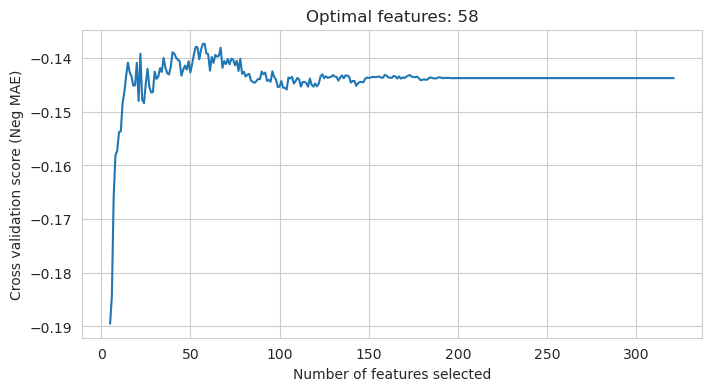

(     C_Atomic number start counting left top, left-right sequence  \
 35                                           33.551829              
 376                                          27.104091              
 761                                          38.878615              
 829                                          30.617966              
 405                                          42.017876              
 ..                                                 ...              
 82                                           28.698219              
 133                                          26.251537              
 366                                          29.541911              
 595                                          38.797152              
 127                                          16.101158              
 
      C_Boiling temperature  C_Compression modulus    C_Density  \
 35             1339.232684               0.257734  4311.122102   
 376            1516.133

In [12]:
from xgboost import XGBRegressor
feature_reduction_auto(X_train, X_test, y_train)

In [18]:
def tune_and_train_xgboost(X_train, y_train):
    print("\n--- Starting Hyperparameter Tuning (XGBoost) ---")

    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42)

    param_dist = {

        'n_estimators': randint(500, 1500),
        
        'learning_rate': uniform(0.01, 0.1),

        'max_depth': randint(3, 8),

        'subsample': uniform(0.6, 0.4),       # 0.6 ~ 1.0
        'colsample_bytree': uniform(0.6, 0.4), # 0.6 ~ 1.0
        
        'reg_alpha': uniform(0, 0.5),
        'reg_lambda': uniform(0.5, 1.0)
    }
    
    # 3. 随机搜索
    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=500,     
        cv=5,       
        scoring='neg_mean_absolute_error',
        n_jobs=4,       
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params: {search.best_params_}")
    print(f"Best CV MAE: {-search.best_score_:.4f} eV/atom")
    
    return search.best_estimator_


# 增强版

In [39]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform 

def tune_and_train_xgboost_enhanced(X_train, y_train):
    print("\n--- Starting Enhanced Hyperparameter Tuning (XGBoost) ---")

    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42)

    param_dist = {
        'n_estimators': randint(500, 3000),
        'learning_rate': loguniform(0.005, 0.2),

        'max_depth': randint(3, 12),

        'min_child_weight': randint(1, 10), 

        'subsample': uniform(0.5, 0.5),    
        'colsample_bytree': uniform(0.5, 0.5), 

        'gamma': uniform(0, 0.5),
        'reg_alpha': loguniform(1e-3, 10.0),  
        'reg_lambda': loguniform(1e-3, 10.0)
    }

    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=1000,    
        cv=10,       
        scoring='neg_mean_absolute_error',
        n_jobs=-1,  
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params: {search.best_params_}")
    print(f"Best CV MAE: {-search.best_score_:.4f} eV/atom")
    
    return search.best_estimator_


--- Starting Feature Reduction ---
[Step 1] Constant features removed. Remaining: 321
[Step 2] Collinear features removed (>0.95). Remaining: 165
[Step 3] Running RFE to select top 58 features...
Final Feature Set: ['C_Boiling temperature', 'C_Compression modulus', 'C_Density', 'C_Distance from valence electron (Schubert)', 'C_Electron affinity'] ...

--- Starting Enhanced Hyperparameter Tuning (XGBoost) ---
Fitting 10 folds for each of 1000 candidates, totalling 10000 fits


/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the '

Best Params: {'colsample_bytree': 0.7421722131457543, 'gamma': 0.006683841629697818, 'learning_rate': 0.022667145998856806, 'max_depth': 11, 'min_child_weight': 8, 'n_estimators': 2982, 'reg_alpha': 0.013290088126145502, 'reg_lambda': 0.006789306844293925, 'subsample': 0.5209927144547941}
Best CV MAE: 0.1201 eV/atom

--- Model Evaluation ---
MAE:  0.1258 eV/atom
RMSE: 0.1943 eV/atom
R2:   0.9234


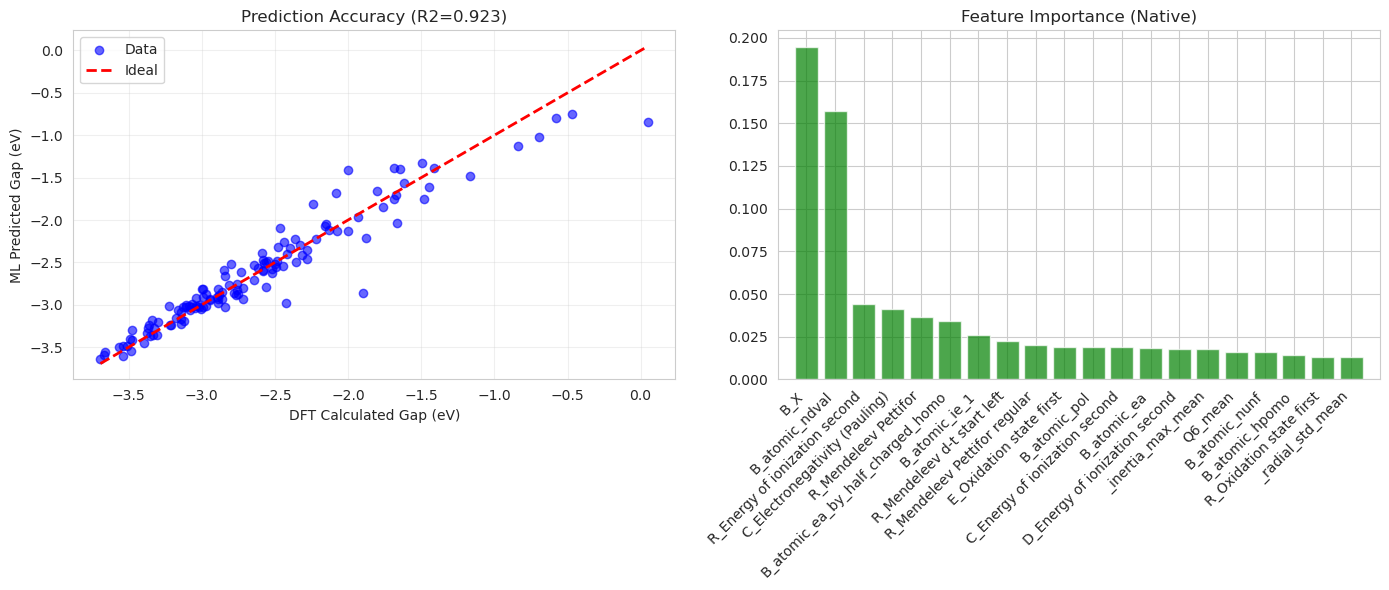

In [40]:
X_train_red, X_test_red = feature_reduction(X_train, X_test, y_train, n_features_to_select=58)
best_model = tune_and_train_xgboost_enhanced(X_train_red, y_train)
evaluate_model(best_model, X_test_red, y_test)

# svr

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

def evaluate_model(model, X_test, y_test, save_path=None):

    print("\n--- Model Evaluation ---")

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MAE:  {mae:.4f} eV/atom")
    print(f"RMSE: {rmse:.4f} eV/atom")
    print(f"R2:   {r2:.4f}")

    if save_path:
        print(f"正在保存预测结果到: {save_path} ...")
        # 确保 X_test 有索引，如果没有就用默认索引
        indices = X_test.index if hasattr(X_test, 'index') else range(len(y_test))
        
        result_df = pd.DataFrame({
            'True_Value': y_test.values if hasattr(y_test, 'values') else y_test,
            'Predicted_Value': y_pred
        }, index=indices)
        
        result_df.to_csv(save_path)
        print("保存成功！")
    
    plt.figure(figsize=(14, 6))
    
    # 图 1: 真实值 vs 预测值
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Data')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')
    plt.xlabel('DFT Calculated Gap (eV)')
    plt.ylabel('ML Predicted Gap (eV)')
    plt.title(f'Prediction Accuracy (R2={r2:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 图 2: 特征重要性
    plt.subplot(1, 2, 2)
    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps.get('svr'), 'feature_importances_'): # SVR通常没有这个，但这行是安全检查
        importances = model.named_steps['svr'].feature_importances_
    else:
        print("Calculating Permutation Importance (this may take a moment)...")
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
        importances = result.importances_mean
        
    if importances is not None:
        indices = np.argsort(importances)[::-1]
        top_n = min(20, len(X_test.columns))
        plt.title("Feature Importance")
        plt.bar(range(top_n), importances[indices[:top_n]], align="center", color='green', alpha=0.7)
        plt.xticks(range(top_n), X_test.columns[indices[:top_n]], rotation=45, ha='right')
        plt.xlim([-1, top_n])
        plt.tight_layout()
    
    plt.show()

In [49]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

def tune_and_train_svr(X_train, y_train):
    print("\n--- Starting Hyperparameter Tuning (SVR) ---")

    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ('svr', SVR())
    ])

    param_dist = {
        'svr__kernel': ['rbf'], 

        'svr__C': loguniform(1e-1, 1e3), 

        'svr__gamma': loguniform(1e-3, 1.0),

        'svr__epsilon': loguniform(1e-3, 1e-1)
    }
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=500,  
        cv=10,       
        scoring='neg_mean_absolute_error',
        n_jobs=-1,       
        verbose=1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params: {search.best_params_}")
    print(f"Best CV MAE: {-search.best_score_:.4f} eV/atom")
    
    return search.best_estimator_

In [50]:
X_train_red, X_test_red = feature_reduction(X_train, X_test, y_train, n_features_to_select=58)
best_model = tune_and_train_svr(X_train_red, y_train)


--- Starting Feature Reduction ---
[Step 1] Constant features removed. Remaining: 321
[Step 2] Collinear features removed (>0.95). Remaining: 165
[Step 3] Running RFE to select top 58 features...
Final Feature Set: ['C_Boiling temperature', 'C_Compression modulus', 'C_Density', 'C_Distance from valence electron (Schubert)', 'C_Electron affinity'] ...

--- Starting Hyperparameter Tuning (SVR) ---
Fitting 10 folds for each of 500 candidates, totalling 5000 fits
Best Params: {'svr__C': 14.673606167579615, 'svr__epsilon': 0.01849083144035026, 'svr__gamma': 0.005938312608859315, 'svr__kernel': 'rbf'}
Best CV MAE: 0.0981 eV/atom



--- Model Evaluation ---
MAE:  0.0977 eV/atom
RMSE: 0.1564 eV/atom
R2:   0.9504
正在保存预测结果到: results_ours_structure.csv ...
保存成功！
Calculating Permutation Importance (this may take a moment)...


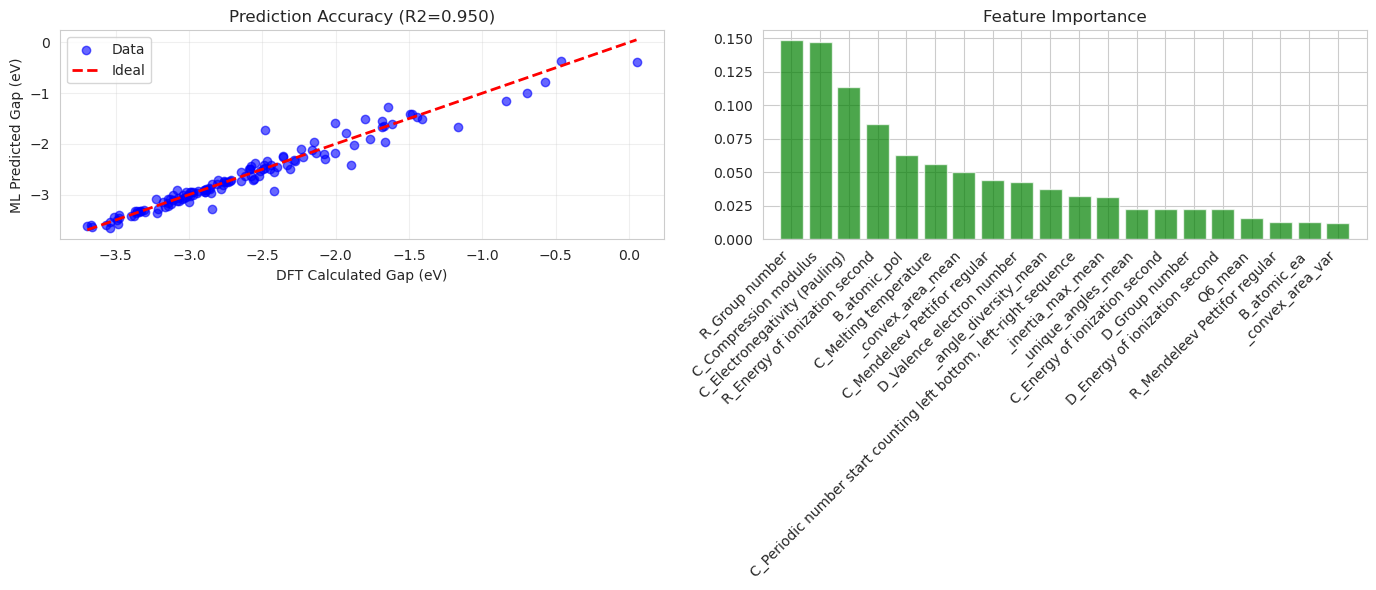

In [51]:
evaluate_model(best_model, X_test_red, y_test,save_path='results_ours_structure.csv')

RMSE 改善: 0.2107 -> 1.0151


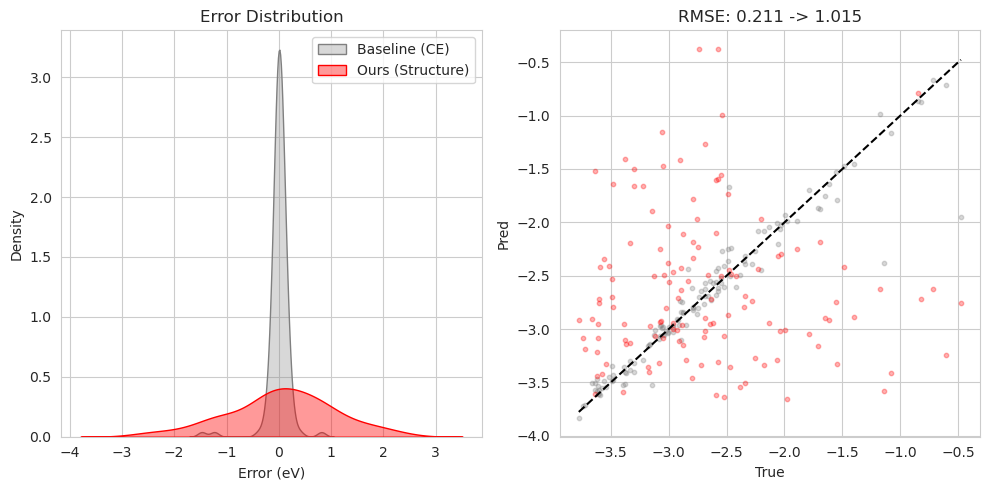

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 读取结果
try:
    df_ce = pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/results_ce_structure.csv', index_col=0)
    df_struct = pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/results_ours_structure.csv', index_col=0)
except FileNotFoundError:
    print("错误：没找到 CSV 文件，请先运行两次模型评估并保存结果！")
else:
    # 对齐数据
    common = df_ce.index.intersection(df_struct.index)
    df_ce, df_struct = df_ce.loc[common], df_struct.loc[common]
    y_true = df_ce['True_Value']
    
    # 计算误差
    rmse_ce = np.sqrt(mean_squared_error(y_true, df_ce['Predicted_Value']))
    rmse_struct = np.sqrt(mean_squared_error(y_true, df_struct['Predicted_Value']))
    
    print(f"RMSE 改善: {rmse_ce:.4f} -> {rmse_struct:.4f}")
    
    # 画图
    plt.figure(figsize=(10, 5))
    
    # 左图：误差分布 (证明离群点减少)
    plt.subplot(1, 2, 1)
    error_ce = df_ce['Predicted_Value'] - y_true
    error_struct = df_struct['Predicted_Value'] - y_true
    sns.kdeplot(error_ce, fill=True, color='gray', label='Baseline (CE)', alpha=0.3)
    sns.kdeplot(error_struct, fill=True, color='red', label='Ours (Structure)', alpha=0.4)
    plt.xlabel('Error (eV)')
    plt.title('Error Distribution')
    plt.legend()
    
    # 右图：Parity Plot
    plt.subplot(1, 2, 2)
    plt.scatter(y_true, df_ce['Predicted_Value'], alpha=0.3, c='gray', s=10)
    plt.scatter(y_true, df_struct['Predicted_Value'], alpha=0.3, c='red', s=10)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
    plt.xlabel('True')
    plt.ylabel('Pred')
    plt.title(f'RMSE: {rmse_ce:.3f} -> {rmse_struct:.3f}')
    
    plt.tight_layout()
    plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

print("--- 正在诊断数据对齐问题 ---")

# 1. 读取刚保存的结构模型结果 (这是标准，RMSE 0.1564 的那个)
try:
    df_struct = pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/results_ours_structure.csv', index_col=0)
except FileNotFoundError:
    print("找不到 results_ours_structure.csv，请先运行 evaluate_model 保存结果。")
    exit()

# 2. 读取之前的 CE 结果
try:
    df_ce = pd.read_csv('/home/gaotianjiao/modnet-master/ext_struc/results_ce_structure.csv', index_col=0)
except FileNotFoundError:
    print("找不到 results_baseline_ce.csv。无法画对比图。")
    print("建议：请重新跑一遍 CE 模型，并保存结果。")
    exit()

# 3. 关键：检查索引是否一致
indices_struct = df_struct.index
indices_ce = df_ce.index

print(f"Structure 样本数: {len(indices_struct)}")
print(f"CE Baseline 样本数: {len(indices_ce)}")

# 取交集 (只对比两个文件里都有的 ID)
common_indices = indices_struct.intersection(indices_ce)
print(f"共同索引数: {len(common_indices)}")

if len(common_indices) < len(indices_struct) * 0.5:
    print("\n严重警告：两个结果文件的索引几乎对不上！")
    print("原因：训练 CE 模型和 Structure 模型时，测试集划分不一致。")
    print("解决：必须保证两个模型使用的是同一组测试集 index。")
else:
    print("\n索引存在交集，正在基于交集重画对比图...")
    
    # --- 强制对齐数据 ---
    df_struct_aligned = df_struct.loc[common_indices]
    df_ce_aligned = df_ce.loc[common_indices]
    
    y_true = df_struct_aligned['True_Value'] # 以当前的真实值为准
    y_pred_struct = df_struct_aligned['Predicted_Value']
    y_pred_ce = df_ce_aligned['Predicted_Value'] # 注意：这里可能因为 CE 预测时用的真实值不一样而有偏差，但我们只取预测值
    
    # 重新计算 RMSE
    rmse_struct = np.sqrt(mean_squared_error(y_true, y_pred_struct))
    
    # 计算 CE 的 RMSE (必须用当前的 y_true 去算 CE 的误差)
    rmse_ce = np.sqrt(mean_squared_error(y_true, y_pred_ce))
    
    print(f"\n[校准后结果]")
    print(f"Ours (Structure) RMSE: {rmse_struct:.4f} ")
    print(f"Baseline (CE)    RMSE: {rmse_ce:.4f}")
    
    if rmse_ce > 0.5:
         print("⚠️ 警告：CE 的误差依然很大。这说明 CE 结果文件里的预测值可能对应的是完全不同的材料。")
         print("建议：不要用旧的 csv，请重新训练 CE 模型并预测当前的 X_test。")
    else:
        # --- 画图 ---
        plt.figure(figsize=(12, 5))
        
        # 误差分布图
        plt.subplot(1, 2, 1)
        sns.kdeplot(y_pred_ce - y_true, fill=True, color='gray', label=f'Baseline (RMSE={rmse_ce:.3f})', alpha=0.3)
        sns.kdeplot(y_pred_struct - y_true, fill=True, color='red', label=f'Ours (RMSE={rmse_struct:.3f})', alpha=0.4)
        plt.title('Error Distribution (Aligned)')
        plt.xlabel('Error (eV)')
        plt.xlim(-0.5, 0.5)
        plt.legend()
        
        # 散点图
        plt.subplot(1, 2, 2)
        plt.scatter(y_true, y_pred_ce, alpha=0.3, c='gray', s=10, label='Baseline')
        plt.scatter(y_true, y_pred_struct, alpha=0.3, c='red', s=10, label='Ours')
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.title('Parity Plot (Aligned)')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

--- 正在诊断数据对齐问题 ---
Structure 样本数: 130
CE Baseline 样本数: 167
共同索引数: 130

索引存在交集，正在基于交集重画对比图...

[校准后结果]
Ours (Structure) RMSE: 0.1564 
Baseline (CE)    RMSE: 0.9849
⚠️ 警告：CE 的误差依然很大。这说明 CE 结果文件里的预测值可能对应的是完全不同的材料。
建议：不要用旧的 csv，请重新训练 CE 模型并预测当前的 X_test。
